# ETL Pipeline - Retail Analytics
Pipeline completo de ETL con visualización en tiempo real.

**Pasos:** Extract → Profile → Clean → Transform → Validate → Load → Queries

In [1]:
# === SETUP ===
import os, sys, warnings
warnings.filterwarnings('ignore')

# Detect environment
IN_COLAB = 'google.colab' in sys.modules
BASE_DIR = os.getcwd()

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_DIR = '/content/drive/MyDrive/ETL-G1_2026-2_U1_Lab/1b'
    os.makedirs(f'{BASE_DIR}/data/output', exist_ok=True)
    os.makedirs(f'{BASE_DIR}/data/processed', exist_ok=True)
    os.makedirs(f'{BASE_DIR}/logs', exist_ok=True)

sys.path.insert(0, f'{BASE_DIR}/src')

import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

print(f'Base dir: {BASE_DIR}')
print('Environment ready')

Base dir: /home/drz/Documents/semesterV/etl/Activities/1ab/1b
Environment ready


In [2]:
# === IMPORT MODULES ===
from extract import extract_all, extract_csv
from profiling import profile_dataframe, save_profile_report
from clean import clean_transactions, clean_references
from transform import transform_all
from validate import validate_all
from load import load_to_csv, load_to_sqlite, load_references_to_sqlite, create_tables
from queries import run_queries
from pathlib import Path

DATA_DIR = Path(BASE_DIR) / 'data'
OUTPUT_DIR = DATA_DIR / 'output'
RAW_DIR = DATA_DIR / 'raw'

print('All modules imported successfully')

All modules imported successfully


---
## STEP 1 — Initialize Database

In [3]:
db_path = DATA_DIR / 'retail_analytics.db'
create_tables(db_path)
print(f'Database initialized: {db_path}')

Database initialized at /home/drz/Documents/semesterV/etl/Activities/1ab/1b/data/retail_analytics.db
Database initialized: /home/drz/Documents/semesterV/etl/Activities/1ab/1b/data/retail_analytics.db


---
## STEP 2 — Extract Data

In [4]:
raw_data = extract_all(RAW_DIR)

# Transaction summary
csv_rows = len(extract_csv(RAW_DIR / 'sales_cali.csv'))
json_rows = len(raw_data['transactions']) - csv_rows
xml_rows = len(raw_data['transactions']) - csv_rows - json_rows + csv_rows

print(f'CSV  (Cali):     {csv_rows} rows')
print(f'JSON (Bogota):   {len(raw_data["transactions"])} total rows')
print(f'Total transactions: {len(raw_data["transactions"])} rows')
print(f'\nReference tables:')
print(f'  products:      {len(raw_data["products"])} rows')
print(f'  stores:        {len(raw_data["stores"])} rows')
print(f'  promotions:    {len(raw_data["promotions"])} rows')
print(f'  targets:       {len(raw_data["targets"])} rows')

print('\n--- Sample: Transactions (first 5 rows) ---')
raw_data['transactions'].head()

CSV  (Cali):     241 rows
JSON (Bogota):   763 total rows
Total transactions: 763 rows

Reference tables:
  products:      15 rows
  stores:        3 rows
  promotions:    6 rows
  targets:       9 rows

--- Sample: Transactions (first 5 rows) ---


,sale_line_id,sale_date,store_id,product_id,quantity,unit_price,promotion_code,payment_method
0,L00001,2026-04-04,S01,P010,1,115000,NaN,Card
1,L00002,2026-02-08,S01,P012,1,35000,NaN,Cash
2,L00003,2026-04-04,S01,P003,3,175000,NaN,Cash
3,L00004,2026-03-29,S01,P001,1,145000,NaN,Cash
4,L00005,2026-02-27,S01,P004,1,390000,NaN,Cash


In [5]:
print('--- Reference: Products ---')
display(raw_data['products'])
print('\n--- Reference: Stores ---')
display(raw_data['stores'])
print('\n--- Reference: Promotions ---')
display(raw_data['promotions'])
print('\n--- Reference: Monthly Targets ---')
display(raw_data['targets'])

--- Reference: Products ---


,product_id,product_name,category,list_price,unit_cost
0,P001,Coffee Maker Basic,Small Appliances,145000,98000
1,P002,Coffee Maker Premium,Small Appliances,285000,205000
2,P003,Blender 500W,Small Appliances,175000,122000
3,P004,Air Fryer 4L,Small Appliances,390000,295000
4,P005,Wireless Headphones,Electronics,220000,155000
5,P006,Bluetooth Speaker,Electronics,165000,112000
6,P007,Smartwatch Active,Electronics,310000,225000
7,P008,USB-C Charger,Electronics,78000,43000
8,P009,Desk Lamp LED,Home & Office,92000,51000
9,P010,Ergonomic Mouse,Home & Office,115000,67000



--- Reference: Stores ---


,store_id,store_name,city,region
0,S01,Cali Norte,Cali,Southwest
1,S02,Bogotá Centro,Bogotá,Central
2,S03,Medellín Poblado,Medellín,Northwest



--- Reference: Promotions ---


,promotion_code,product_id,start_date,end_date,discount_pct,campaign_name
0,PROMO10,P001,2026-02-10,2026-02-28,0.10,Coffee Week
1,PROMO15,P004,2026-03-01,2026-03-20,0.15,Kitchen Days
2,PROMO12,P005,2026-03-15,2026-04-05,0.12,Audio Campaign
3,PROMO08,P009,2026-02-20,2026-03-10,0.08,Home Office
4,PROMO20,P013,2026-04-01,2026-04-25,0.20,Personal Care Month
5,PROMO10B,P007,2026-04-10,2026-04-30,0.10,Wearables Week



--- Reference: Monthly Targets ---


,store_id,month,sales_target
0,S01,2026-02,19500000
1,S01,2026-03,20500000
2,S01,2026-04,21500000
3,S02,2026-02,23000000
4,S02,2026-03,24000000
5,S02,2026-04,25000000
6,S03,2026-02,20500000
7,S03,2026-03,21500000
8,S03,2026-04,22500000


---
## STEP 3 — Profile Data

In [6]:
profiles = {}
for name, df in raw_data.items():
    profiles[name] = profile_dataframe(df, name)

# Save report
report_path = save_profile_report(profiles, OUTPUT_DIR)

# Print summary table
summary_rows = []
for name, prof in profiles.items():
    summary_rows.append({
        'Dataset': name,
        'Rows': prof['rows'],
        'Columns': prof['num_columns'],
        'Total Nulls': prof['total_nulls'],
        'Duplicates': prof['duplicates']
    })
display(pd.DataFrame(summary_rows))

print(f'\nFull report saved to: {report_path}')

,Dataset,Rows,Columns,Total Nulls,Duplicates
0,transactions,763,8,489,3
1,products,15,5,0,0
2,stores,3,4,0,0
3,promotions,6,6,0,0
4,targets,9,3,0,0



Full report saved to: /home/drz/Documents/semesterV/etl/Activities/1ab/1b/data/output/profile_report.txt


In [7]:
# Detailed profile: transactions
tp = profiles['transactions']
print('=== Transaction Profile Details ===')
print(f'Rows: {tp["rows"]}')
print(f'Duplicate sale_line_id: {tp.get("duplicate_sale_line_id", 0)}')
print(f'Invalid quantities: {tp.get("invalid_quantities", 0)} ({tp.get("invalid_quantity_pct", 0)}%)')
print(f'Invalid prices: {tp.get("invalid_prices", 0)} ({tp.get("invalid_price_pct", 0)}%)')
print(f'Invalid dates: {tp.get("invalid_dates", 0)} ({tp.get("invalid_date_pct", 0)}%)')

if tp['nulls_per_column']:
    print('\nNulls per column:')
    for col, count in tp['nulls_per_column'].items():
        print(f'  {col}: {count}')
else:
    print('\nNo null values found')

=== Transaction Profile Details ===
Rows: 763
Duplicate sale_line_id: 3
Invalid quantities: 2 (0.26%)
Invalid prices: 2 (0.26%)
Invalid dates: 1 (0.13%)

Nulls per column:
  promotion_code: 489


---
## STEP 4 — Clean Data

In [8]:
n_before = len(raw_data['transactions'])

cleaned_transactions = clean_transactions(raw_data['transactions'])
cleaned_refs = clean_references(
    raw_data['products'], raw_data['stores'],
    raw_data['promotions'], raw_data['targets']
)

n_after = len(cleaned_transactions)
removed = n_before - n_after

print(f'Rows before cleaning: {n_before}')
print(f'Rows after cleaning:  {n_after}')
print(f'Rows removed:         {removed}')
print(f'  - Duplicates: {n_before - len(raw_data["transactions"].drop_duplicates(subset="sale_line_id"))}')
print(f'\nCleaned transactions sample:')
cleaned_transactions.head()

Rows before cleaning: 763
Rows after cleaning:  755
Rows removed:         8
  - Duplicates: 3

Cleaned transactions sample:


,sale_line_id,sale_date,store_id,product_id,quantity,unit_price,promotion_code,payment_method
0,L00001,2026-04-04,S01,P010,1,115000.0,nan,CARD
1,L00002,2026-02-08,S01,P012,1,35000.0,nan,CASH
2,L00003,2026-04-04,S01,P003,3,175000.0,nan,CASH
3,L00004,2026-03-29,S01,P001,1,145000.0,nan,CASH
4,L00005,2026-02-27,S01,P004,1,390000.0,nan,CASH


In [9]:
# Verify case normalization
print('Store IDs:', sorted(cleaned_transactions['store_id'].unique()))
print('Product IDs:', sorted(cleaned_transactions['product_id'].unique()))
print('Payment methods:', sorted(cleaned_transactions['payment_method'].unique()))
print(f'\nDate range: {cleaned_transactions["sale_date"].min()} to {cleaned_transactions["sale_date"].max()}')

Store IDs: ['S01', 'S02', 'S03']
Product IDs: ['P001', 'P002', 'P003', 'P004', 'P005', 'P006', 'P007', 'P008', 'P009', 'P010', 'P011', 'P012', 'P013', 'P014', 'P015']
Payment methods: ['CARD', 'CASH', 'TRANSFER']

Date range: 2026-02-01 00:00:00 to 2026-04-30 00:00:00


---
## STEP 5 — Transform Data

In [10]:
integrated = transform_all(
    cleaned_transactions,
    cleaned_refs['products'],
    cleaned_refs['stores'],
    cleaned_refs['promotions'],
    cleaned_refs['targets']
)

print(f'Total rows after transform: {len(integrated)}')
print(f'Columns: {list(integrated.columns)}')
print(f'\nDerived columns sample:')
integrated[['sale_line_id', 'product_name', 'store_name', 'quantity',
            'unit_price', 'gross_sales', 'discount_amount', 'net_sales',
            'month', 'day_name']].head(10)

Total rows after transform: 755
Columns: ['sale_line_id', 'sale_date', 'store_id', 'product_id', 'quantity', 'unit_price', 'promotion_code', 'payment_method', 'product_name', 'category', 'store_name', 'city', 'region', 'discount_pct', 'campaign_name', 'gross_sales', 'discount_amount', 'net_sales', 'month', 'week', 'day_name', 'sales_target']

Derived columns sample:


,sale_line_id,product_name,store_name,quantity,unit_price,gross_sales,discount_amount,net_sales,month,day_name
0,L00001,Ergonomic Mouse,Cali Norte,1,115000.0,115000.0,0.0,115000.0,2026-04,Saturday
1,L00002,Notebook Pack,Cali Norte,1,35000.0,35000.0,0.0,35000.0,2026-02,Sunday
2,L00003,Blender 500W,Cali Norte,3,175000.0,525000.0,0.0,525000.0,2026-04,Saturday
3,L00004,Coffee Maker Basic,Cali Norte,1,145000.0,145000.0,0.0,145000.0,2026-03,Sunday
4,L00005,Air Fryer 4L,Cali Norte,1,390000.0,390000.0,0.0,390000.0,2026-02,Friday
5,L00006,Wireless Headphones,Cali Norte,2,220000.0,440000.0,0.0,440000.0,2026-04,Saturday
6,L00007,Blender 500W,Cali Norte,2,175000.0,350000.0,0.0,350000.0,2026-03,Friday
7,L00008,Smartwatch Active,Cali Norte,2,310000.0,620000.0,62000.0,558000.0,2026-04,Monday
8,L00009,USB-C Charger,Cali Norte,1,78000.0,78000.0,0.0,78000.0,2026-02,Friday
9,L00010,USB-C Charger,Cali Norte,2,78000.0,156000.0,0.0,156000.0,2026-04,Monday


---
## STEP 6 — Validate Data

In [11]:
validation = validate_all(integrated, cleaned_refs)

print(f'Validation passed: {validation["passed"]}')
if validation['errors']:
    for err in validation['errors']:
        print(f'  ERROR: {err}')
else:
    print('\nAll validations passed:')
    print('  - Unique sale_line_id')
    print('  - Foreign key integrity')
    print('  - Positive sales values')
    print('  - Formula correctness (net_sales = gross_sales - discount_amount)')

Validation passed: True

All validations passed:
  - Unique sale_line_id
  - Foreign key integrity
  - Positive sales values
  - Formula correctness (net_sales = gross_sales - discount_amount)


---
## STEP 7 — Load Data

In [12]:
# CSV export
csv_path = DATA_DIR / 'processed' / 'sales_analytics.csv'
load_to_csv(integrated, csv_path)
print(f'CSV exported: {csv_path} ({len(integrated)} rows)')

# SQLite load
load_to_sqlite(integrated, 'sales_analytics', db_path)
print(f'Loaded into sales_analytics table')

# Reference tables
load_references_to_sqlite(cleaned_refs, db_path)
print(f'\nAll data loaded into {db_path}')

CSV exported: /home/drz/Documents/semesterV/etl/Activities/1ab/1b/data/processed/sales_analytics.csv (755 rows)
Loaded into sales_analytics table
  Loaded 15 rows into products
  Loaded 3 rows into stores
  Loaded 6 rows into promotions
  Loaded 9 rows into monthly_targets

All data loaded into /home/drz/Documents/semesterV/etl/Activities/1ab/1b/data/retail_analytics.db


In [13]:
# Verify database tables
import sqlite3
conn = sqlite3.connect(str(db_path))

tables = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table'", conn)
print('Tables in database:')
display(tables)

for table in tables['name']:
    count = pd.read_sql_query(f'SELECT COUNT(*) as cnt FROM {table}', conn).iloc[0, 0]
    print(f'  {table}: {count} rows')

conn.close()

Tables in database:


,name
0,products
1,stores
2,promotions
3,monthly_targets
4,sales_analytics


  products: 15 rows
  stores: 3 rows
  promotions: 6 rows
  monthly_targets: 9 rows
  sales_analytics: 755 rows


---
## STEP 8 — Analytical Queries

In [14]:
results = run_queries(db_path)

for name, df in results.items():
    print(f'\n===== {name.upper().replace("_", " ")} =====')
    display(df)


===== TOP PRODUCTS =====


,product_id,product_name,category,total_net_sales,total_units
0,P004,Air Fryer 4L,Small Appliances,32292000.0,84
1,P003,Blender 500W,Small Appliances,22225000.0,127
2,P005,Wireless Headphones,Electronics,21874600.0,101
3,P002,Coffee Maker Premium,Small Appliances,15675000.0,55
4,P013,Hair Dryer,Personal Care,13284000.0,102
5,P010,Ergonomic Mouse,Home & Office,12765000.0,111
6,P001,Coffee Maker Basic,Small Appliances,10918500.0,76
7,P009,Desk Lamp LED,Home & Office,10145760.0,111
8,P007,Smartwatch Active,Electronics,10044000.0,33
9,P008,USB-C Charger,Electronics,8190000.0,105



===== MONTHLY PERFORMANCE =====


,store_id,store_name,month,sales_target,actual_sales,achievement_pct
0,S01,Cali Norte,2026-02,19500000.0,22867500.0,117.27
1,S02,Bogotá Centro,2026-02,23000000.0,21549200.0,93.69
2,S03,Medellín Poblado,2026-02,20500000.0,18451000.0,90.00
3,S01,Cali Norte,2026-03,20500000.0,18213200.0,88.84
4,S02,Bogotá Centro,2026-03,24000000.0,19242540.0,80.18
5,S03,Medellín Poblado,2026-03,21500000.0,23463420.0,109.13
6,S01,Cali Norte,2026-04,21500000.0,20354000.0,94.67
7,S02,Bogotá Centro,2026-04,25000000.0,21361000.0,85.44
8,S03,Medellín Poblado,2026-04,22500000.0,15289000.0,67.95



===== REGIONAL ANALYSIS =====


...

,region,total_net_sales,total_units,num_stores
0,Central,62152740.0,402,1
1,Southwest,61434700.0,386,1
2,Northwest,57203420.0,358,1



===== SALES BY CATEGORY =====


,category,total_net_sales,total_units,num_products
0,Small Appliances,81110500.0,342,4
1,Electronics,46873600.0,280,4
2,Home & Office,30830760.0,360,4
3,Personal Care,21976000.0,164,3



===== GOAL COMPLIANCE =====


,store_id,store_name,month,sales_target,actual_sales,achievement_pct,status
0,S01,Cali Norte,2026-02,19500000.0,22867500.0,117.27,Met
1,S02,Bogotá Centro,2026-02,23000000.0,21549200.0,93.69,Not Met
2,S03,Medellín Poblado,2026-02,20500000.0,18451000.0,90.00,Not Met
3,S01,Cali Norte,2026-03,20500000.0,18213200.0,88.84,Not Met
4,S02,Bogotá Centro,2026-03,24000000.0,19242540.0,80.18,Not Met
5,S03,Medellín Poblado,2026-03,21500000.0,23463420.0,109.13,Met
6,S01,Cali Norte,2026-04,21500000.0,20354000.0,94.67,Not Met
7,S02,Bogotá Centro,2026-04,25000000.0,21361000.0,85.44,Not Met
8,S03,Medellín Poblado,2026-04,22500000.0,15289000.0,67.95,Not Met


In [15]:
# Save all outputs
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
for f in OUTPUT_DIR.glob('*.csv'):
    f.unlink()
for name, df in results.items():
    df.to_csv(OUTPUT_DIR / f'{name}.csv', index=False)
print(f'Saved {len(results)} query result files to {OUTPUT_DIR}')

Saved 6 query result files to /home/drz/Documents/semesterV/etl/Activities/1ab/1b/data/output


---
## STEP 9 — Business Analysis Charts

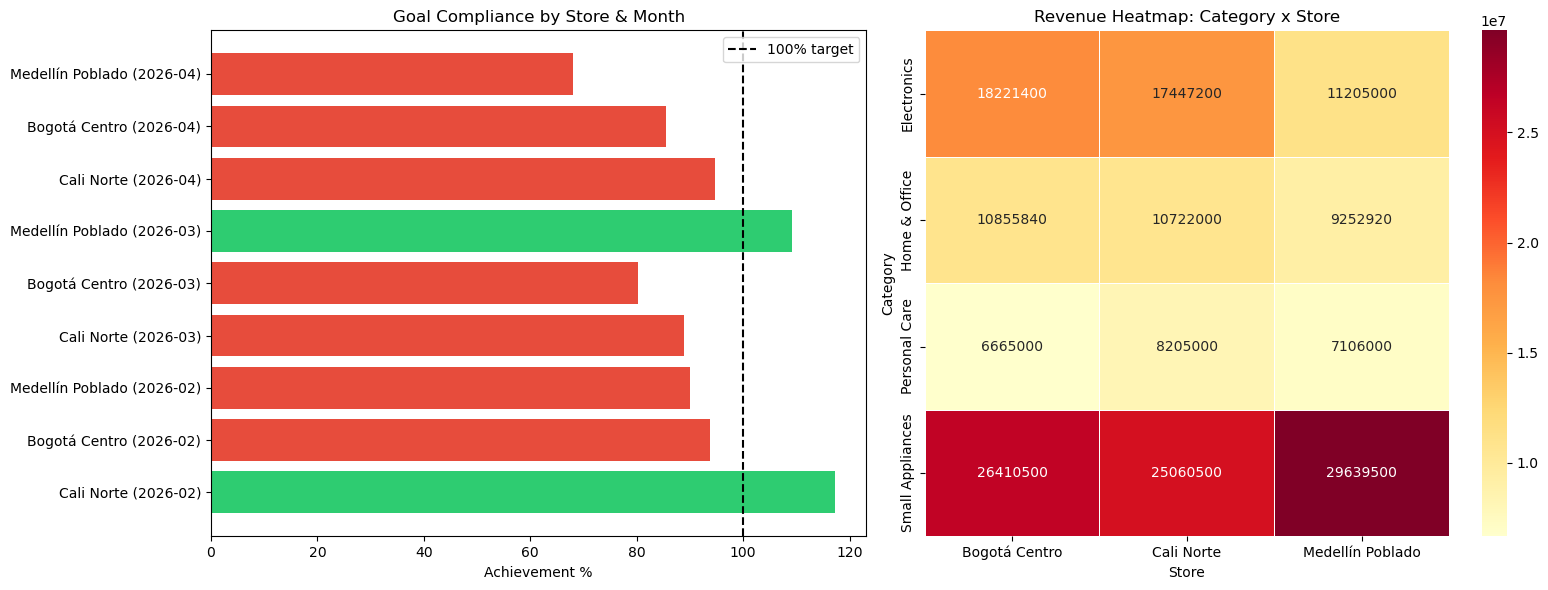

In [21]:
# 3. Goal compliance by store and month
gc = results['goal_compliance'].copy()
gc['label'] = gc['store_name'] + ' (' + gc['month'] + ')'
colors = ['#2ecc71' if s == 'Met' else '#e74c3c' for s in gc['status']]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(gc['label'], gc['achievement_pct'], color=colors)
axes[0].axvline(x=100, color='black', linestyle='--', label='100% target')
axes[0].set_xlabel('Achievement %')
axes[0].set_title('Goal Compliance by Store & Month')
axes[0].legend()

# 4. Revenue heatmap: Category x Store
pivot = integrated.pivot_table(
    values='net_sales', index='category', columns='store_name', aggfunc='sum'
)
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd', linewidths=0.5, ax=axes[1])
axes[1].set_title('Revenue Heatmap: Category x Store')
axes[1].set_ylabel('Category')
axes[1].set_xlabel('Store')

plt.tight_layout()
plt.show()

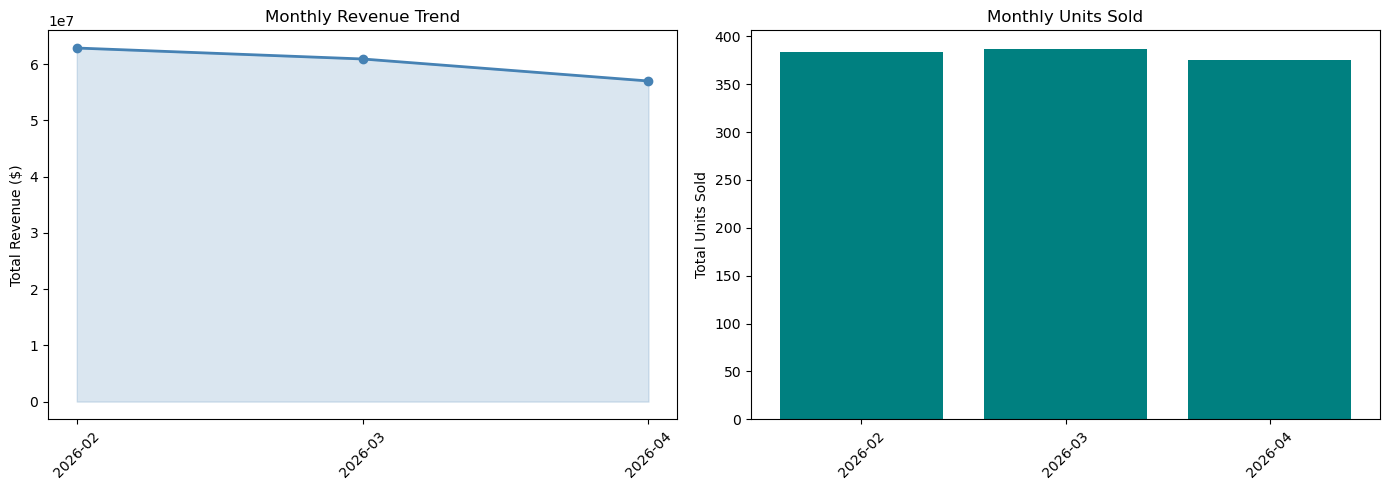

In [22]:
# 5. Monthly trend: revenue over time
monthly_trend = integrated.groupby('month').agg(
    total_sales=('net_sales', 'sum'),
    total_units=('quantity', 'sum'),
    avg_ticket=('net_sales', 'mean')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(monthly_trend['month'], monthly_trend['total_sales'], marker='o', color='steelblue', linewidth=2)
axes[0].fill_between(monthly_trend['month'], monthly_trend['total_sales'], alpha=0.2, color='steelblue')
axes[0].set_ylabel('Total Revenue ($)')
axes[0].set_title('Monthly Revenue Trend')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(monthly_trend['month'], monthly_trend['total_units'], color='teal')
axes[1].set_ylabel('Total Units Sold')
axes[1].set_title('Monthly Units Sold')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

---
## Pipeline Summary

In [23]:
print('=' * 60)
print('         ETL PIPELINE - COMPLETED SUCCESSFULLY')
print('=' * 60)
print(f'\n  Raw rows:       {len(raw_data["transactions"])}')
print(f'  Cleaned rows:   {n_after}')
print(f'  Rows removed:   {removed}')
print(f'  Integrated:     {len(integrated)}')
print(f'  Validation:     {"PASSED" if validation["passed"] else "FAILED"}')
print(f'\n  Database:       {db_path}')
print(f'  CSV output:     {csv_path}')
print(f'  Query results:  {OUTPUT_DIR}')
print(f'  Profile report: {report_path}')
print('\n  Files saved:')
for f in sorted(OUTPUT_DIR.glob('*.csv')):
    print(f'    - {f.name}')
print('=' * 60)

         ETL PIPELINE - COMPLETED SUCCESSFULLY

  Raw rows:       763
  Cleaned rows:   755
  Rows removed:   8
  Integrated:     755
  Validation:     PASSED

  Database:       /home/drz/Documents/semesterV/etl/Activities/1ab/1b/data/retail_analytics.db
  CSV output:     /home/drz/Documents/semesterV/etl/Activities/1ab/1b/data/processed/sales_analytics.csv
  Query results:  /home/drz/Documents/semesterV/etl/Activities/1ab/1b/data/output
  Profile report: /home/drz/Documents/semesterV/etl/Activities/1ab/1b/data/output/profile_report.txt

  Files saved:
    - goal_compliance.csv
    - monthly_performance.csv
    - regional_analysis.csv
    - sales_by_category.csv
    - sales_by_region.csv
    - top_products.csv
